In [55]:
import os
import pennylane as qml
from pennylane import numpy as np
import numpy as onp
import matplotlib.pyplot as plt
import pandas as pd

from qiskit import QuantumCircuit
from pennylane.templates import StronglyEntanglingLayers


In [70]:
import torch
import torch.nn as nn
from torch.optim import Adam

In [56]:
n_ansatz_layers = 1
n_layers = 5
n_qubits = 5


In [57]:
dev_parallel = qml.device("default.qubit", wires = n_qubits)

def S(x):
    for w in range(n_qubits):
        qml.RY(x[w], wires = w)

def W(theta):
    
    for l in range(n_ansatz_layers):
        for w in range(n_qubits):
            qml.Rot(theta[l,w,0], theta[l,w,1], theta[l,w,2], wires = w)

        for w in range(n_qubits-1):
            qml.CNOT(wires = [w, w+1])

        qml.CNOT(wires = [n_qubits-1,0])


@qml.qnode(dev_parallel)
def circuit_parallel(params, x=None):
    for l in range(n_layers):
        S(x)
        W(params[l])
    
    #W(params[n_layers-1])

    #return [qml.expval(qml.PauliZ(wires = i)) for i in range(n_qubits)]
    return qml.expval(qml.PauliZ(wires = 0))

In [75]:
class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.classical = nn.Sequential(
             nn.Linear(n_qubits,1),
             nn.Tanh()
        ).double()

        
        self.q_params = nn.Parameter(
            0.01 * torch.randn(
                n_layers,
                n_ansatz_layers,
                n_qubits,
                3,
                dtype = torch.float64
            )
        )
    
    def forward(self, x_batch):
        q_outputs  = []

        for x in x_batch:
            q_out = circuit_parallel(self.q_params, x)
            q_outputs.append(q_out)
        
        q_outputs = torch.stack(q_outputs)
        q_outputs = q_outputs.reshape(-1,1)

        y_pred = self.classical(q_outputs)
       
        return y_pred.squeeze()

In [76]:
X = torch.tensor(
    [
        [0.1, 0.15, 0.2, 0.25, 0.3],
        [0.15, 0.2, 0.25, 0.3, 0.25],
        [0.2, 0.25, 0.3, 0.25, 0.2],
        [0.25, 0.3, 0.25, 0.2, 0.15],
        [0.3, 0.25, 0.2, 0.15, 0.1],
    ],
        dtype=torch.float64
    
)


y = torch.tensor(
    [0.25, 0.2, 0.15, 0.1, 0.15],
    dtype = torch.float64
)

In [77]:
model = HybridModel
optimizer = optim.Adam(model.p)

NameError: name 'optim' is not defined

In [58]:
params_parallel = 2 * np.pi * np.random.random( size = (n_layers, n_ansatz_layers, n_qubits, 3))
print(params_parallel)

[[[[1.15255478e+00 4.89894304e+00 3.75012014e+00]
   [2.80124980e+00 6.28160922e-01 2.88554589e+00]
   [2.09675304e+00 8.97658691e-01 4.08965289e+00]
   [3.54444404e-01 4.53645208e+00 5.89710059e+00]
   [4.89313009e-03 6.23424909e+00 3.87975075e+00]]]


 [[[3.84313015e+00 4.43989051e-02 1.44905490e-01]
   [3.29725643e+00 2.51240058e+00 2.93209009e-01]
   [6.11828637e+00 1.46254547e+00 5.69297018e-01]
   [3.88543389e+00 2.40307956e+00 6.17782186e+00]
   [2.93275775e+00 5.40316493e+00 4.27449833e+00]]]


 [[[2.83057028e+00 8.33462091e-02 5.92002823e+00]
   [3.53924425e+00 2.42164331e+00 1.00318921e-01]
   [1.45074869e+00 1.51440767e+00 4.29307130e+00]
   [3.83272204e+00 5.23511803e+00 1.08928224e+00]
   [2.45710626e+00 1.14502311e+00 4.74607571e+00]]]


 [[[2.67133314e+00 1.30653600e+00 3.56696636e+00]
   [1.96747219e-01 5.29223132e+00 2.82588856e+00]
   [2.48280216e+00 5.82236937e+00 4.56958472e+00]
   [2.05171616e+00 3.58420520e+00 3.27249817e+00]
   [6.03922194e+00 5.30636267e+00 4.69

(<Figure size 3800x600 with 1 Axes>, <Axes: >)

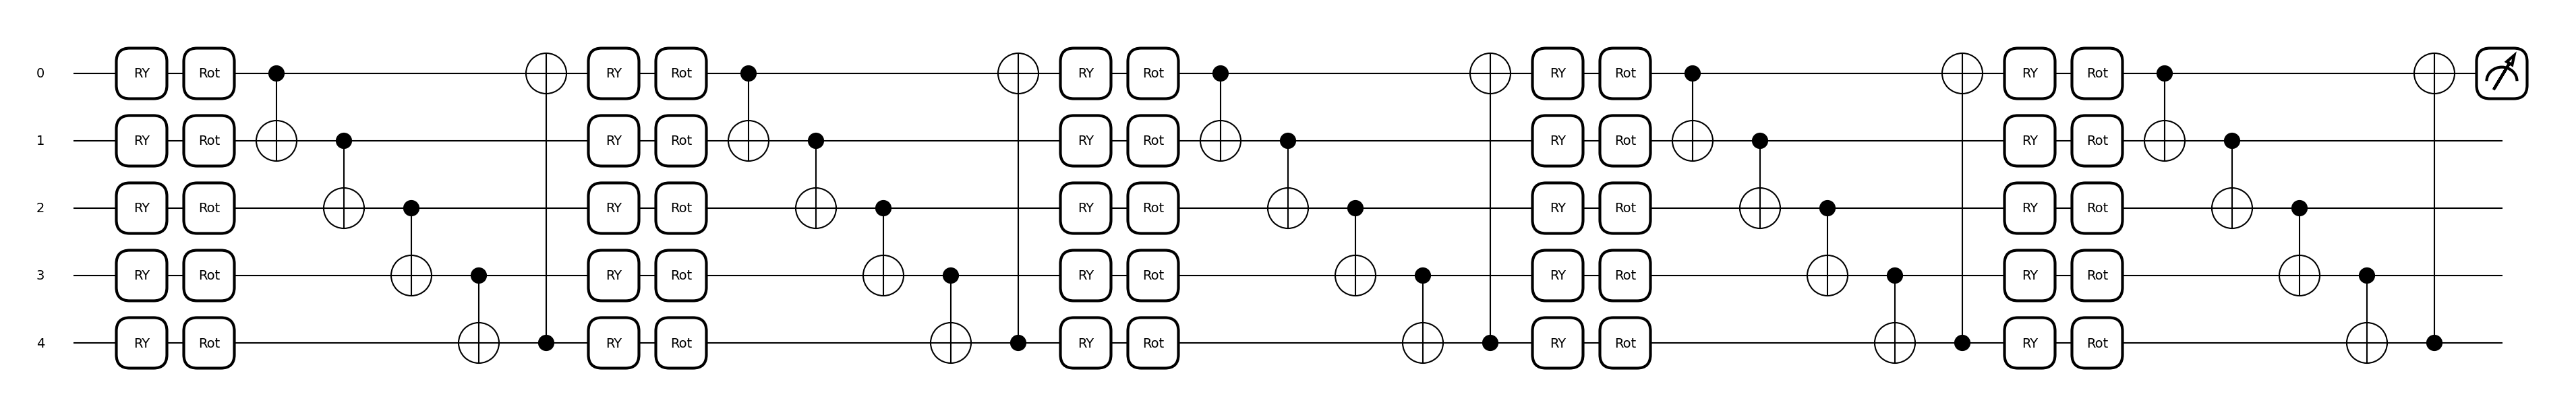

In [59]:
x1 = [0.5 for i in range(n_qubits)]
qml.draw_mpl(circuit_parallel)(params_parallel, x=x1)
#fig, ax = qml.draw_mpl(circuit_parallel, level="device")(params_parallel, x=x)
#plt.show()


In [60]:
np.random.seed(42)

def square_loss(targets, predictions):
    
    loss = 0
    for (t,p) in zip(targets,predictions):
        loss += (t-p)**2

    loss = 0.5 * (loss/len(targets))
    return loss

In [61]:
def cost(params, x , y):
    predictions = [ circuit_parallel(params, x = x_) for x_ in x]
    return square_loss(y, predictions)

In [62]:
file_path = "SPEI_AllScales_Napak - SPEI_AllScales_Napak.csv"
df = pd.read_csv(file_path)

In [63]:
#df.index = pd.to_datetime


def df_to_X_y(df, window_size = 5):
    df_as_np = df.to_numpy()
    X = []
    y = []
    for i in range(len(df_as_np) - window_size):
        row = [[a] for a in df_as_np[i:i+5]]
        X.append(row)
        label = df_as_np[i+5]
        y.append(label)
    return onp.array(X), onp.array(y)

In [64]:
WS = n_qubits
col_E = df.iloc[:, 4]
X,y = df_to_X_y(col_E, WS)
X.shape, y.shape

((534, 5, 1), (534,))

In [65]:
X_train, y_train = X[:334], y[:334]
X_val, y_val = X[334:434], y[334:434]
X_test, y_test = X[434:], y[434:]

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((334, 5, 1), (334,), (100, 5, 1), (100,))

In [66]:
#for x_ in X_train:
#    print(x_)

circuit_parallel(params_parallel, X_train[0])

tensor([0.33676652], requires_grad=True)

In [67]:
cst = [cost(params_parallel, X_train, y_train)]
opt = qml.AdamOptimizer(0.3)
n_iter = 200
batch_size = 100


In [68]:
cst

[tensor([5796.91322188], requires_grad=True)]

In [ ]:
for steps in range(n_iter):
    batch_index = np.random.randint(0, len(X_train), (batch_size,))
    x_batch = X_train[batch_index]
    y_batch = y_train[batch_index]

    params_parallel = opt.step(lambda p: cost(p, x_batch, y_batch), params_parallel)

    c = cost(params_parallel, X_train, y_train)
    cst.append(c)
    if ((steps +1) % 10) == 0 :
        print( "Cost at step {0:3}: {1}".format(steps+1, c))
    

Cost at step  10: [5793.22187408]
Cost at step  20: [5792.17458357]
Cost at step  30: [5790.61418147]
Cost at step  40: [5792.38835205]
Cost at step  50: [5794.80518153]
Cost at step  60: [5791.90166563]
Cost at step  70: [5793.01853835]
Cost at step  80: [5792.02525356]
Cost at step  90: [5792.95320597]
Cost at step 100: [5791.89387179]
Cost at step 110: [5790.70252343]
Cost at step 120: [5793.77212267]
Cost at step 130: [5794.08548407]
Cost at step 140: [5791.4350269]
Cost at step 150: [5792.84740829]
Cost at step 160: [5792.72849972]
Cost at step 170: [5792.76453226]
Cost at step 180: [5792.42898208]
Cost at step 190: [5793.7376537]
Cost at step 200: [5793.13428568]
